In [65]:
import pandas as pd

# Convertendo o link de edição para um link de exportação CSV
sheet_id = '1w7vBNjmeu3v327z5Kp664H6Tuc4J2fkS_aZAN6vmccw'
csv_url = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'

try:
    df = pd.read_csv(csv_url)
    print("Dados carregados com sucesso via CSV (sem necessidade de login)!")
    display(df.head())
except Exception as e:
    print(f"Erro ao carregar: {e}. Certifique-se de que a planilha está configurada como 'Qualquer pessoa com o link' pode ler.")

Dados carregados com sucesso via CSV (sem necessidade de login)!


,Carimbo de data/hora,Você ficou gripado no ano passado ?,Você tomou vacina da gripe no ano passado?,"Você frequentou no ano passado, semanalmente ambientes com muitas pessoas? (salas cheias, ônibus, eventos, etc.)",Você viajou no ano passado mais de 100 km de distância?,"Você tem alergia nas vias aéreas (rinite, sinusite, etc.)?",Quantas horas você dormiu em média por noite no ano passado?,Você praticou atividade física no ano passado?,Você se alimentou de forma balanceada no ano passado?,"Em média, quantas vezes você lavou as mãos por dia no ano passado?","Na sua percepção, o seu nível de estresse no ano passado foi:"
0,24/03/2026 15:01:35,Sim,Sim,Sim,Poucas vezes por ano,Médio,4 horas ou menos,Sim,Às vezes,3 a 5 vezes,5.0
1,24/03/2026 15:04:20,Sim,Sim,Sim,Nuca,Não,entre 4 e 6 horas,Não,"Não, raramente",Mais de 10 vezes,3.0
2,24/03/2026 15:04:20,Sim,Não,Sim,Poucas vezes por ano,Pouco,mais de 6 horas,Sim,Às vezes,6 a 10 vezes,3.0
3,24/03/2026 15:04:37,Sim,Não,Não,Nuca,Muito,mais de 6 horas,Sim,Às vezes,2 vezes ou menos,2.0
4,24/03/2026 15:05:27,Sim,Sim,Sim,Pelo menos uma vez por mês,Médio,entre 4 e 6 horas,Não,Às vezes,6 a 10 vezes,4.0


In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, accuracy_score
from sklearn.impute import SimpleImputer

# --- AJUSTE O VALOR DE K AQUI ---
k_vizinhos = 48
# ------------------------------

# 1. Limpeza básica
target_col = 'Você ficou gripado no ano passado ?'
X = df.drop(columns=['Carimbo de data/hora', target_col], errors='ignore')
y = df[target_col]

# 2. Pré-processamento
X = pd.get_dummies(X, drop_first=True)
imputer = SimpleImputer(strategy='most_frequent')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

le = LabelEncoder()
y = le.fit_transform(y)

# 3. Divisão de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5. Criar e treinar o modelo KNN (Usando weights='distance' para bater com o teste)
knn = KNeighborsClassifier(n_neighbors=k_vizinhos, weights='distance')
knn.fit(X_train, y_train)

# 6. Avaliação
y_pred = knn.predict(X_test)

print(f'Modelo KNN treinado com K = {k_vizinhos} e pesos por distância')
print(f'Acurácia do Modelo: {accuracy_score(y_test, y_pred):.2f}')
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Modelo KNN treinado com K = 48 e pesos por distância
Acurácia do Modelo: 0.68

Relatório de Classificação:
              precision    recall  f1-score   support

         Não       1.00      0.20      0.33        15
         Sim       0.66      1.00      0.79        23

    accuracy                           0.68        38
   macro avg       0.83      0.60      0.56        38
weighted avg       0.79      0.68      0.61        38



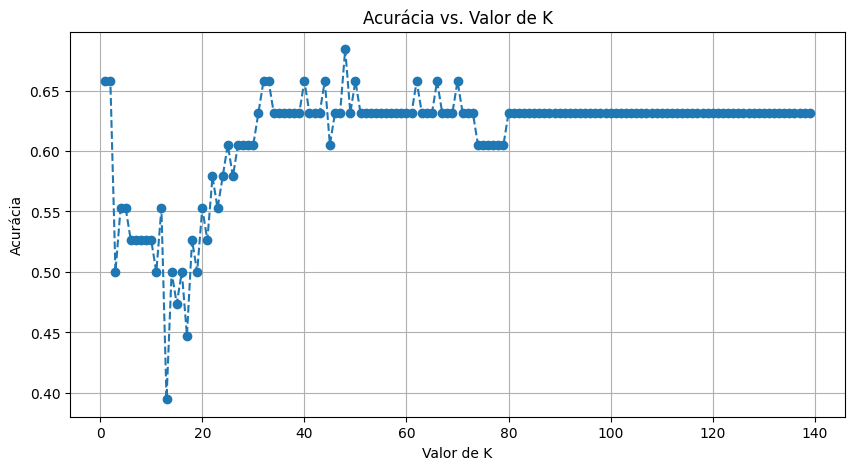

O melhor valor de K encontrado foi: 48 com acurácia de 0.68


In [67]:
import matplotlib.pyplot as plt

# Testando diferentes valores de K para ver qual tem melhor acurácia
scores = []
valores_k = range(1, 140, 1) # Testa K de 1 a 30 (apenas ímpares)

for k in valores_k:
    modelo_teste = KNeighborsClassifier(n_neighbors=k, weights='distance')
    modelo_teste.fit(X_train, y_train)
    scores.append(modelo_teste.score(X_test, y_test))

# Plotando o resultado
plt.figure(figsize=(10, 5))
plt.plot(valores_k, scores, marker='o', linestyle='dashed')
plt.title('Acurácia vs. Valor de K')
plt.xlabel('Valor de K')
plt.ylabel('Acurácia')
plt.grid(True)
plt.show()

melhor_k = valores_k[np.argmax(scores)]
print(f'O melhor valor de K encontrado foi: {melhor_k} com acurácia de {max(scores):.2f}')